# Image Augmentation using OpenCV  
## Pattern and Visual Recognition – Unit I

This notebook demonstrates major image augmentation techniques used in computer vision:

### Geometric Augmentation
- Translation
- Rotation
- Scaling
- Shear
- Flip

### Photometric Augmentation
- Brightness
- Contrast
- Gamma Correction
- Noise
- Blur

Goal: Understand how augmentation improves model robustness and generalization.


Saving 4A57E79A-4CE5-467E-B073-54D1441CE141_1_102_o.jpeg to 4A57E79A-4CE5-467E-B073-54D1441CE141_1_102_o.jpeg


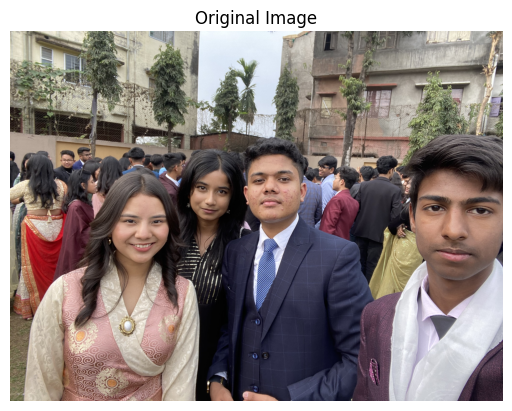

In [ ]:
#Load Libraries and Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()


## 🔹 Translation (Shifting)

Translation moves the image in x and y direction.

### Mathematical Model
\[
x' = x + t_x
\]
\[
y' = y + t_y
\]

### Purpose
- Simulates camera movement.
- Improves position invariance.


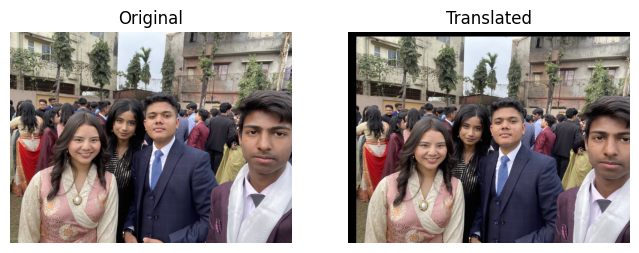

In [2]:
tx, ty = 60, 40

M_translate = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])

translated = cv2.warpAffine(img, M_translate, (w, h))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(translated)
plt.title("Translated")
plt.axis("off")
plt.show()


## 🔹 Rotation

Rotation changes the orientation of the image.

**Mathematical Model** &nbsp;&nbsp;&nbsp;
$\begin{smallmatrix}x'\\y'\end{smallmatrix}
=
\begin{smallmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{smallmatrix}
\begin{smallmatrix}x\\y\end{smallmatrix}$

### Purpose
- Orientation robustness.
- Object rotation invariance.


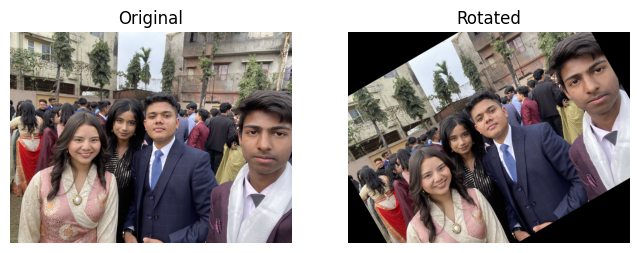

In [3]:
angle = 30
M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
rotated = cv2.warpAffine(img, M_rot, (w, h))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rotated)
plt.title("Rotated")
plt.axis("off")
plt.show()


## Scaling (Zoom)

Scaling changes the size of the image.

**Mathematical Model** &nbsp;&nbsp;&nbsp;
$\begin{smallmatrix}x'\\y'\end{smallmatrix}
=
\begin{smallmatrix}s_x & 0\\ 0 & s_y\end{smallmatrix}
\begin{smallmatrix}x\\y\end{smallmatrix}$


### Purpose
- Scale invariance.
- Distance robustness.


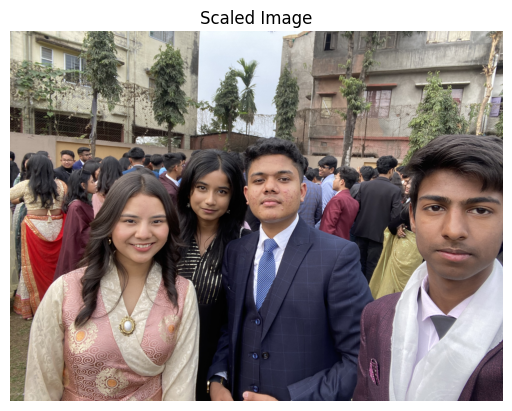

In [5]:
scaled = cv2.resize(img, None, fx=1.3, fy=1.3)

plt.imshow(scaled)
plt.title("Scaled Image")
plt.axis("off")
plt.show()


## Shear

Shear slants the image.

**X-Shear**
&nbsp;&nbsp;&nbsp;\[
x' = x + k y
\]

**Y-Shear** &nbsp;&nbsp;&nbsp;
\[
y' = y + k x
\]

### Purpose
- Viewpoint distortion simulation.


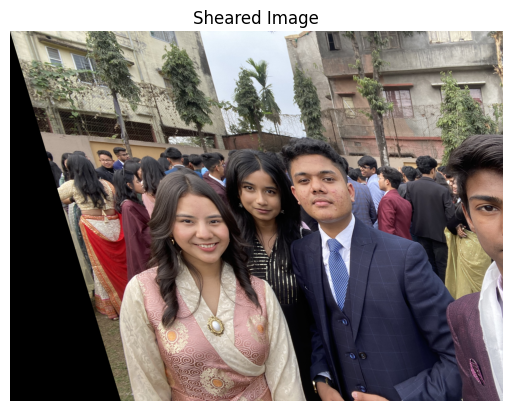

In [6]:
kx = 0.3
M_shear = np.float32([
    [1, kx, 0],
    [0, 1, 0]
])

sheared = cv2.warpAffine(img, M_shear, (w, h))

plt.imshow(sheared)
plt.title("Sheared Image")
plt.axis("off")
plt.show()


## Flip (Reflection)

Flip mirrors the image.

**Horizontal Flip** &nbsp;&nbsp;&nbsp;
\[
x' = -x
\]

**Vertical Flip** &nbsp;&nbsp;&nbsp;
\[
y' = -y
\]

### Purpose
- Symmetry robustness.


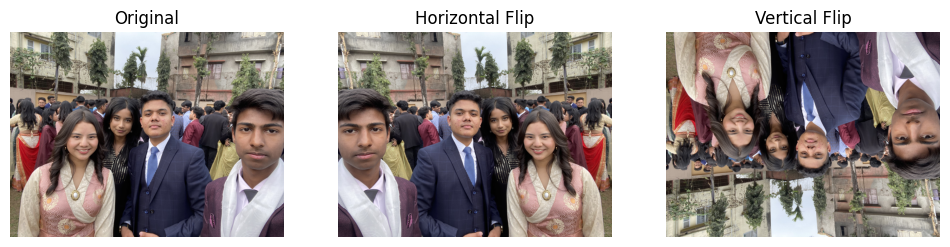

In [7]:
flip_h = cv2.flip(img, 1)
flip_v = cv2.flip(img, 0)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(flip_h)
plt.title("Horizontal Flip")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(flip_v)
plt.title("Vertical Flip")
plt.axis("off")
plt.show()


## Brightness and Contrast

**Brightness** &nbsp;&nbsp;&nbsp;&nbsp;
I' = I + β


**Contrast** &nbsp;&nbsp;&nbsp;&nbsp;
I' = α I


### Purpose
- Lighting variation robustness.


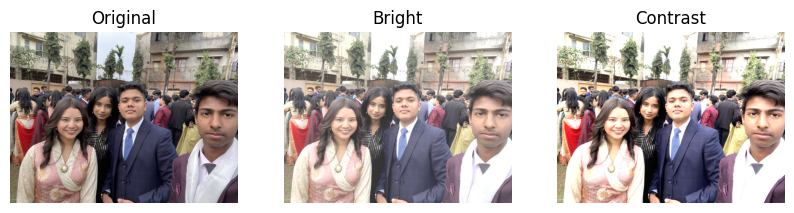

In [8]:
bright = cv2.convertScaleAbs(img, alpha=1, beta=50)
contrast = cv2.convertScaleAbs(img, alpha=1.5, beta=0)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(bright)
plt.title("Bright")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(contrast)
plt.title("Contrast")
plt.axis("off")
plt.show()


## Gamma Correction


I' = I^γ


### Purpose
- Exposure control.


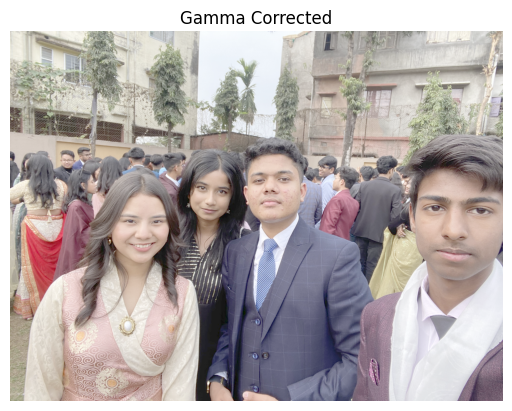

In [9]:
gamma = 0.5
gamma_img = np.array(255 * (img / 255) ** gamma, dtype='uint8')

plt.imshow(gamma_img)
plt.title("Gamma Corrected")
plt.axis("off")
plt.show()


## Noise and Blur

Noise simulates sensor imperfections.
Blur simulates motion or defocus.


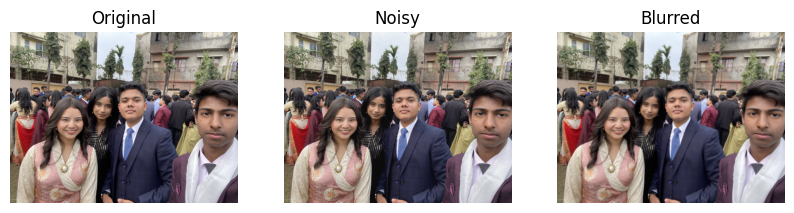

In [10]:
noise = np.random.normal(0, 25, img.shape)
noisy = img + noise
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

blur = cv2.GaussianBlur(img, (9,9), 2)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy)
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(blur)
plt.title("Blurred")
plt.axis("off")
plt.show()


# Color Augmentation

Color augmentation modifies the color properties of an image without changing its spatial structure.

Instead of changing pixel positions, it changes:
- Hue (color type)
- Saturation (color strength)
- Value / Brightness (light intensity)
- Channel distribution (RGB manipulation)

Color augmentation improves robustness to:
- Lighting changes  
- Camera sensor differences  
- Weather conditions  
- Color distortion  


## Color Space Concept

Most images are stored in **RGB** format.

However, color augmentation is easier in **HSV color space**:
- H → Hue (color type)
- S → Saturation (color intensity)
- V → Brightness

Transformation:
RGB → HSV → Modify → RGB


In [ ]:
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

h, s, v = cv2.split(hsv)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(h, cmap='gray')
plt.title("Hue Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(s, cmap='gray')
plt.title("Saturation Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title("Value (Brightness) Channel")
plt.axis("off")

plt.show()


##Hue Augmentation

Hue controls the color type (red, green, blue, etc.).

Mathematical idea:&nbsp;&nbsp;&nbsp;&nbsp;
H' = H + Δ H


Purpose:
- Simulates color variation.
- Makes model invariant to color shifts.


In [ ]:
hue_shift = 30   # change color tone

h_new = (h + hue_shift) % 180   # OpenCV hue range: 0–179

hsv_hue = cv2.merge([h_new, s, v])
hue_aug = cv2.cvtColor(hsv_hue, cv2.COLOR_HSV2RGB)

plt.imshow(hue_aug)
plt.title("Hue Augmented Image")
plt.axis("off")
plt.show()


## Saturation Augmentation

Saturation controls color intensity.

Mathematical idea:&nbsp;&nbsp;&nbsp;&nbsp;
S' = α S

Purpose:
- Simulates dull vs vibrant lighting.


In [ ]:
sat_scale = 1.5

s_new = np.clip(s * sat_scale, 0, 255).astype(np.uint8)

hsv_sat = cv2.merge([h, s_new, v])
sat_aug = cv2.cvtColor(hsv_sat, cv2.COLOR_HSV2RGB)

plt.imshow(sat_aug)
plt.title("Saturation Augmented Image")
plt.axis("off")
plt.show()


## Value (Brightness) Augmentation

Value controls light intensity.

Mathematical idea:&nbsp;&nbsp;&nbsp;&nbsp;
V' = V + β

Purpose:
- Simulates illumination variation.


In [ ]:
value_shift = 40

v_new = np.clip(v + value_shift, 0, 255).astype(np.uint8)

hsv_val = cv2.merge([h, s, v_new])
val_aug = cv2.cvtColor(hsv_val, cv2.COLOR_HSV2RGB)

plt.imshow(val_aug)
plt.title("Brightness (Value) Augmented Image")
plt.axis("off")
plt.show()


## Channel Shuffle Augmentation

Randomly rearranging RGB channels.

Purpose:
- Improves color invariance.
- Prevents overfitting to color patterns.


In [ ]:
r, g, b = cv2.split(img)
shuffled = cv2.merge([g, r, b])

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(shuffled)
plt.title("Channel Shuffled")
plt.axis("off")
plt.show()


##Summary

| Category | Transformations |
|------------|------------------|
| **Geometric** | Translation, Rotation, Scaling, Shear, Flip |
| **Photometric** | Brightness, Contrast, Gamma, Noise, Blur |
| **Color** | Hue Shift, Saturation Scaling, Value (Brightness) Adjustment, Channel Shuffle |

### Augmentation improves:
-  Dataset size  
-  Model generalization  
-  Robustness to real-world variation  
-  Invariance to lighting and color changes  
